In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import torchvision.datasets as datasets
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
from torch.optim.lr_scheduler import StepLR
from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter

from typing import Dict, Tuple
from tqdm import tqdm
import numpy as np
import time
import os
import random
from tabulate import tabulate

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

%matplotlib inline

if __name__ == "__main__":
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.device_count() > 0 else "No GPU detected")



Torch version: 2.7.0+cu126
CUDA available: True
CUDA version: 12.6
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4090


In [2]:
from waveguide_dataset import WaveguideDataset
dataset = WaveguideDataset('train_test_split.h5')

In [3]:
class Flatten(nn.Module):
    def forward(self, x):
        return torch.flatten(x, 1)

class Net4(nn.Module):
    """
    Deeper and wider CNN + FC architecture for regression on waveguide input with conditional features.
    """
    def __init__(self):
        super(Net4, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),    # [B, 64, 32, 32]
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # [B, 128, 32, 32]
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(2),                                         # [B, 128, 16, 16]
            nn.Dropout(0.25),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # [B, 256, 16, 16]
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d(2),                                         # [B, 256, 8, 8]
            nn.Dropout(0.25),

            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1), # [B, 512, 8, 8]
            nn.BatchNorm2d(512),
            nn.GELU(),
            nn.MaxPool2d(2),                                         # [B, 512, 4, 4]
            nn.Dropout(0.25),

            Flatten()                                                # [B, 512 * 4 * 4 = 8192]
        )

        self.fc = nn.Sequential(
            nn.Linear(8192 + 4, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 8)  # Output
        )

    def forward(self, x_img, x_cond):
        x = self.cnn(x_img)                 # [B, 8192]
        x = torch.cat((x, x_cond), dim=1)   # [B, 8196]
        return self.fc(x)

In [4]:
class Net4_Mode0Weight0(nn.Module):
    """
    Net4 variant that predicts only:
    - mode 0  (original index 0)
    - weight0 (original index 4)
    Output shape: [B, 2]
    """
    def __init__(self):
        super().__init__()

        # ---------- CNN trunk (unchanged) ----------
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            Flatten()                               # -> [B, 8192]
        )

        # ---------- Fully-connected head ----------
        self.fc = nn.Sequential(
            nn.Linear(8192 + 4, 2048), nn.BatchNorm1d(2048), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(2048, 1024),     nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, 256),      nn.BatchNorm1d(256),  nn.GELU(), nn.Dropout(0.25),
            nn.Linear(256, 2)                           # <- predict [mode0, weight0]
        )

    def forward(self, x_img, x_cond):
        x = self.cnn(x_img)                   # [B, 8192]
        x = torch.cat((x, x_cond), dim=1)     # [B, 8196]
        return self.fc(x)                     # [B, 2]


In [5]:
# def train(model, device, train_loader_in, optimizer, loss_fn):
#     model.train()
#     i = 0
#     train_loader = tqdm(train_loader_in)
#     for target, p, x in train_loader:
#         i += 1
#         target, p, x = target.to(device), p.to(device), x.to(device)
#         optimizer.zero_grad()
#         output = model(x, p)
#         loss = loss_fn(output, target)
#         loss.backward()
#         optimizer.step()
#         train_loader.set_description(f"loss: {loss.item():.4f}")
def train(model, device, loader, optimizer, loss_fn):
    """
    Train for one epoch.

    · model expects to output **2 values** (mode-0, weight-0)  
    · `target` coming from the dataset is **8-dim** ⇒ we slice columns 0 and 4
    """
    model.train()
    pbar = tqdm(loader, desc="loss: ----")

    for target, params, waveguide in pbar:
        # move to device
        target, params, waveguide = (
            target.to(device),
            params.to(device),
            waveguide.to(device),
        )

        # ■ keep only mode-0 (index 0) and weight-0 (index 4)
        y_true = torch.stack([target[:, 0], target[:, 4]], dim=1)  # shape [B, 2]

        # forward / backward
        optimizer.zero_grad()
        y_pred = model(waveguide, params)        # shape [B, 2]
        loss   = loss_fn(y_pred, y_true)
        loss.backward()
        optimizer.step()

        # progress-bar
        pbar.set_description(f"loss: {loss.item():.4f}")
        
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Net4_Mode0Weight0().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=1)


In [ ]:
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
def test(model, device, loader, loss_fn, dataset, epoch_num, total_epochs):
    """
    Evaluate model for one epoch.

    * Model outputs   → shape [B, 2]   (mode-0, weight-0)
    * Full target has → shape [B, 8]; we slice indices 0 and 4.

    Returns
    -------
    float
        Average MSE loss over the test set.
    """
    model.eval()
    total_loss = 0.0
    collected  = []  # store up to 50 (target, output, params) triplets

    # fetch scalar stats for denormalization
    mode_mean_log = float(dataset.meanm[0])
    mode_std_log  = float(dataset.stdm[0])
    wt_mean_log   = float(dataset.meanw[0])
    wt_std_log    = float(dataset.stdw[0])

    with torch.no_grad():
        for target, params, waveguide in tqdm(loader, desc="Testing"):
            target, params, waveguide = (
                target.to(device),
                params.to(device),
                waveguide.to(device),
            )

            # --- slice ground-truth to 2-dim ---
            y_true = torch.stack([target[:, 0], target[:, 4]], dim=1)  # [B,2]

            # forward
            y_pred = model(waveguide, params)

            # accumulate loss
            batch_loss = loss_fn(y_pred, y_true).item()
            total_loss += batch_loss * waveguide.size(0)

            # collect some samples for plotting
            for t, o, p in zip(y_true.cpu(), y_pred.cpu(), params.cpu()):
                if len(collected) < 50:
                    # --- apply correct log-normalization inverse ---
                    t_mode0_log   = t[0].item() * mode_std_log + mode_mean_log
                    t_weight0_log = t[1].item() * wt_std_log + wt_mean_log
                    o_mode0_log   = o[0].item() * mode_std_log + mode_mean_log
                    o_weight0_log = o[1].item() * wt_std_log + wt_mean_log

                    t_mode0   = np.expm1(t_mode0_log)
                    t_weight0 = np.expm1(t_weight0_log)
                    o_mode0   = np.expm1(o_mode0_log)
                    o_weight0 = np.expm1(o_weight0_log)

                    collected.append((
                        np.array([t_mode0, t_weight0]),
                        np.array([o_mode0, o_weight0]),
                        p.numpy()
                    ))

    avg_loss = total_loss / len(loader.dataset)
    print(f"\nTest set: Average loss: {avg_loss:.4f}\n")

    # ---------- plot on last epoch ----------
    if epoch_num == total_epochs - 1 and collected:
        chosen = random.sample(collected, 8)

        fig, (ax_mode, ax_weight) = plt.subplots(
            1, 2, figsize=(12, 4), sharex=True
        )

        # separate plots for modes and weights
        for tgt, out, prm in chosen:
            ax_mode.plot([0], [tgt[0]],  'ro')
            ax_mode.plot([0], [out[0]],  'bx')
            ax_weight.plot([0], [tgt[1]], 'ro')
            ax_weight.plot([0], [out[1]], 'bx')

        ax_mode.set_title("Mode-0")
        ax_weight.set_title("Weight-0")
        for ax in (ax_mode, ax_weight):
            ax.set_xticks([0])
            ax.set_xticklabels(['value'])
            ax.grid(True)

        plt.suptitle("Targets (red) vs Outputs (blue) on last epoch")
        plt.tight_layout()
        plt.show()

    return avg_loss


Epoch #0:


Testing: 100%|██████████| 180/180 [00:20<00:00,  8.66it/s]



Test set: Average loss: 0.1616

Epoch #1:


Testing: 100%|██████████| 180/180 [00:20<00:00,  8.65it/s]



Test set: Average loss: 0.1196

Epoch #2:


...


Test set: Average loss: 0.0696

Epoch #198:


Testing: 100%|██████████| 180/180 [00:20<00:00,  8.81it/s]



Test set: Average loss: 0.0674

Epoch #199:


Testing: 100%|██████████| 180/180 [00:22<00:00,  7.98it/s]


Test set: Average loss: 0.0665



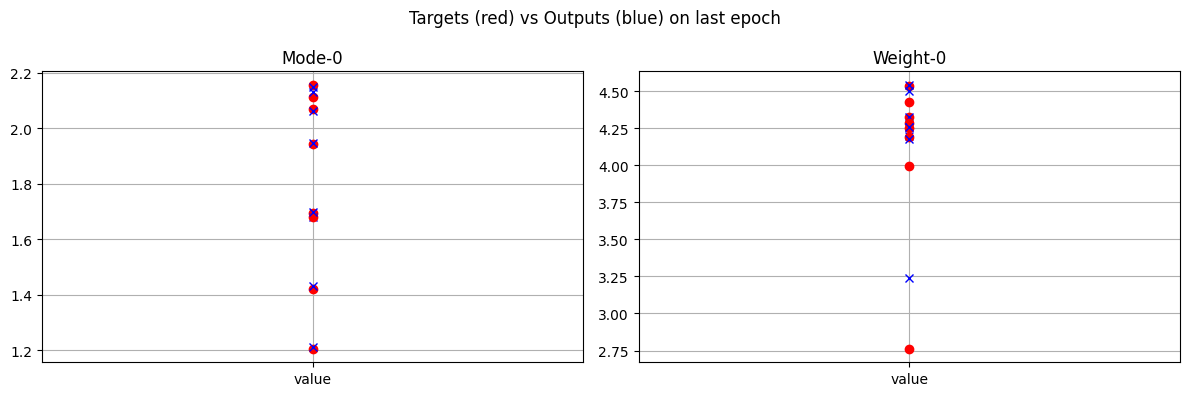

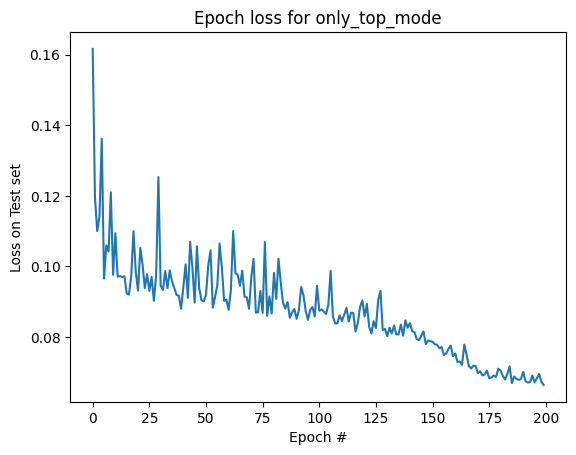

In [ ]:
def main(dataset):
    os.makedirs("models", exist_ok=True)
    batch_size = 128
    test_batch_size = 1000
    lr = 2e-3
    gamma = 0.9
    epochs = 200
    save_dir = 'only_top_mode_correct_norm'
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = Net4_Mode0Weight0().to(device)
    # optimizer = optim.Adam(model.parameters(), lr=lr)
    # scheduler = StepLR(optimizer, step_size=1, gamma=gamma)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.MSELoss()

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False, num_workers=4)
    # pbar_train = tqdm(train_loader)
    # pbar_test = tqdm(test_loader)
    e_loss_graph = []
    for epoch in range(epochs):
        print(f'Epoch #{epoch}:')
        train(model, device, train_loader, optimizer, loss_fn)
        e_loss = test(model, device, test_loader, loss_fn, dataset, epoch, epochs)
        e_loss_graph.append(e_loss)
        scheduler.step()
        torch.save(model.state_dict(), f'models/{save_dir}.pth')
    plt.title(f"Epoch loss for {save_dir}")
    plt.plot(range(epochs), e_loss_graph)
    plt.xlabel('Epoch #')
    plt.ylabel("Loss on Test set")
if __name__ == '__main__':
    main(dataset)